# Part I: model generare poezii

1. Import din drive model de generare poezie

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp /content/drive/MyDrive/modele/poetgpt5.zip .

!unzip poetgpt5.zip -d poetgpt5


Mounted at /content/drive
Archive:  poetgpt5.zip
   creating: poetgpt5/checkpoint-5000/
   creating: poetgpt5/checkpoint-5350/
   creating: poetgpt5/runs/
  inflating: poetgpt5/config.json    
  inflating: poetgpt5/generation_config.json  
  inflating: poetgpt5/tokenizer_config.json  
  inflating: poetgpt5/model.safetensors  
  inflating: poetgpt5/merges.txt     
  inflating: poetgpt5/added_tokens.json  
  inflating: poetgpt5/vocab.json     
  inflating: poetgpt5/special_tokens_map.json  
  inflating: poetgpt5/tokenizer.json  
  inflating: poetgpt5/checkpoint-5000/config.json  
  inflating: poetgpt5/checkpoint-5000/generation_config.json  
  inflating: poetgpt5/checkpoint-5000/tokenizer_config.json  
  inflating: poetgpt5/checkpoint-5000/training_args.bin  
  inflating: poetgpt5/checkpoint-5000/trainer_state.json  
  inflating: poetgpt5/checkpoint-5000/model.safetensors  
  inflating: poetgpt5/checkpoint-5000/merges.txt  
  inflating: poetgpt5/checkpoint-5000/optimizer.pt  
  inflating

2. Incarcare modelului meu si tokenizer pentru folosire

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

MODEL_PATH = "./poetgpt5"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, local_files_only=True)

if tokenizer.eos_token != "<|endofpoem|>":
    tokenizer.eos_token = "<|endofpoem|>"

generator = pipeline("text-generation", model=model, tokenizer=tokenizer)


Device set to use cuda:0


3. Generare poezie si curatare

In [ ]:

import re

def curata_poezie_generata(text_generat):
    """
    Curăță o poezie generată cu tokeni de formă <|...|> și se asigură că se termină corect.
    Păstrează structura pe versuri și strofe.
    """

    lines = text_generat.strip().split("\n")
    poezie_curata = []
    colectare = False

    for line in lines:
        line_strip = line.strip()


        if re.match(r"^<\|.*?\|>$", line_strip):
            continue

        if line_strip == "<|poezie=>":
            colectare = True
            continue

        if "<|poezie=" in line_strip:
            line = line.split("<|poezie=")[-1]
            if line.strip().endswith("|>"):
                line = line.replace("|>", "").strip()
            colectare = True

        if line_strip.endswith("|>"):
            line = line.replace("|>", "").strip()

        if line_strip == ">":
            continue

        if colectare:
            poezie_curata.append(line.strip())

    if poezie_curata:
        ultim = poezie_curata[-1].strip()
        if ultim and not ultim.endswith((".", "!", "?", "...")):
            if re.match(r".*[a-zA-ZăîâșțĂÎÂȘȚ]$", ultim):
                poezie_curata[-1] = ultim + "."
            else:
                poezie_curata[-1] = re.sub(r"[^\w\s]", "", ultim) + "."

    return "\n".join(poezie_curata)


def genereaza_poezie(generator, autor, titlu, max_versuri=None):
    prompt = f"<|autor={autor}|>\n<|titlu={titlu}|>\n<|poezie=>\n"

    output = generator(
        prompt,
        do_sample=True,
        temperature=0.8,
        top_k=50,
        top_p=0.95,
        repetition_penalty=1.1,
        max_new_tokens=512,
        eos_token_id=tokenizer.convert_tokens_to_ids("<|endofpoem|>")
    )

    text_generat = output[0]["generated_text"]

    if "<|endofpoem|>" in text_generat:
        text_generat = text_generat.split("<|endofpoem|>")[0]

    return curata_poezie_generata(text_generat)


In [ ]:
poezie = genereaza_poezie(
    generator=generator,
    autor="George Bacovia",
    titlu="Amintiri de iarnă",
    max_versuri=15
)

print(poezie)


Deodată se-aude un foșnet în pod
În care se izbesc de geamuri-amândouă
Odaia noastră dragă, o noapte de iarnă.

Așa cum foșnetul s-apropie muiat
Cu fiecare fereastră-n parte
Ca un codru ce-și mișcă frunzele-mpreună,
Unda se-oprește și ascultă...
Amintirile din această noapte
Se-amestecă-n somn cu foșnetul din casă;
Plâng amoarele din noi la geamuri,
Plâng sărutările ce le-ascundem sub pleoape,
Și toate trec ca niște umbre de oameni
Prin ploaia înghețată.


In [ ]:


autori = [
    "Mihai Eminescu",
    "Lucian Blaga",
    "George Bacovia",
    "Tudor Arghezi",
    "Ana Blandiana",
    "Marin Sorescu"
]

prompturi = [
    "Umbre și dor",
    "Amurg violet",
    "Lacom de iubire",
    "Înapoi în timpul din nisip",
    "Inimi de lut"
]

output_file = "poezii_generate.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for autor in autori:
        for titlu in prompturi:
            for i in range(3):
                poezie = genereaza_poezie(
                    generator=generator,
                    autor=autor,
                    titlu=titlu,
                    max_versuri=50
                )
                f.write(f"Autor: {autor}\n")
                f.write(f"Titlu: {titlu}\n")
                f.write(poezie.strip() + "\n")
                f.write("=" * 40 + "\n\n")

print("✅ Poeziile au fost generate și salvate în 'poezii_generate.txt'")


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


✅ Poeziile au fost generate și salvate în 'poezii_generate.txt'


In [ ]:
import re

def curata_poezii(input_path, output_path):
    with open(input_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    poezii_curatate = []
    poezie_curenta = []

    for line in lines:
        line_strip = line.strip()

        if line_strip.startswith("Autor:") or line_strip.startswith("Titlu:") or line_strip.startswith("==="):
            if poezie_curenta:
                versuri = [v for v in poezie_curenta]
                if versuri:
                    ultim = versuri[-1].strip()
                    if ultim and not ultim.endswith((".", "!", "?", "...")):
                        if re.match(r".*[a-zA-ZăîâșțĂÎÂȘȚ]$", ultim):
                            versuri[-1] = ultim + "."
                        else:
                            versuri[-1] = re.sub(r"[^\w\s]", "", ultim) + "."
                poezii_curatate.extend(versuri + [""])
                poezie_curenta = []
            poezii_curatate.append(line_strip)
            continue


        if re.match(r"^<\|.*?\|>$", line_strip):
            continue

        if line_strip == "<|poezie=>":
            continue


        if "<|poezie=" in line:
            line = line.split("<|poezie=")[-1]


        if line.strip().endswith("|>"):
            line = line.replace("|>", "").strip()

        if line_strip == ">":
            continue

        if line_strip == "":
            poezie_curenta.append("")
        else:
            poezie_curenta.append(line.strip())

    if poezie_curenta:
        versuri = [v for v in poezie_curenta]
        if versuri:
            ultim = versuri[-1].strip()
            if ultim and not ultim.endswith((".", "!", "?", "...")):
                if re.match(r".*[a-zA-ZăîâșțĂÎÂȘȚ]$", ultim):
                    versuri[-1] = ultim + "."
                else:
                    versuri[-1] = re.sub(r"[^\w\s]", "", ultim) + "."
        poezii_curatate.extend(versuri)


    with open(output_path, "w", encoding="utf-8") as f:
        for line in poezii_curatate:
            f.write(line + "\n")

curata_poezii("poezii_generate.txt", "poezii_generate_curatate.txt")


Metrici poezii perplexitate slef rouge selg bleu


In [ ]:
!pip install nltk rouge-score transformers

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=11f194dec826c1e4ee346c89ce9042e1333642010927a174c95f5480e87635fe
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score


In [ ]:

!pip install nltk rouge-score transformers


import nltk
nltk.download('punkt')

import torch
from nltk.translate.bleu_score import sentence_bleu
from rouge_score import rouge_scorer
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
import numpy as np

MODEL_PATH = "./poetgpt5"
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH, local_files_only=True)
model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, local_files_only=True)
model.eval()

def incarca_poezii(path):
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    poezii = []
    curenta = []
    for line in lines:
        if line.strip() == "========================================":
            if curenta:
                poezii.append("\n".join(curenta).strip())
                curenta = []
        elif not (line.startswith("Autor:") or line.startswith("Titlu:")):
            curenta.append(line.strip())
    return poezii

poezii = incarca_poezii("poezii_generate_curatate.txt")



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [ ]:

def calculeaza_perplexity(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs["input_ids"])
        loss = outputs.loss
        return torch.exp(loss).item()

perplexities = [calculeaza_perplexity(p) for p in poezii]


In [ ]:
def simple_tokenize(text):
    return text.lower().replace("\n", " ").split()

In [ ]:
# === SELF-BLEU ===

def calculeaza_self_bleu(poezii):
    scoruri = []
    for i in range(len(poezii)):
        ipoteza = simple_tokenize(poezii[i])
        referinte = [simple_tokenize(p) for j, p in enumerate(poezii) if j != i]
        try:
            scor = sentence_bleu(referinte, ipoteza)
            scoruri.append(scor)
        except:
            scoruri.append(0.0)
    return scoruri

In [ ]:

# === SELF-ROUGE ===

from rouge_score import rouge_scorer

def calculeaza_self_rouge_multi(poezii, tipuri=["rouge1", "rouge2", "rougeL"]):
    results = {tip: [] for tip in tipuri}
    scorer = rouge_scorer.RougeScorer(tipuri, use_stemmer=True)

    for i in range(len(poezii)):
        ipoteza = poezii[i]
        referinte = [p for j, p in enumerate(poezii) if j != i]
        for tip in tipuri:
            scoruri_tip = []
            for ref in referinte:
                scor = scorer.score(ipoteza, ref)[tip].fmeasure
                scoruri_tip.append(scor)
            results[tip].append(np.mean(scoruri_tip))
    return results


In [ ]:
import nltk
nltk.download('punkt')

from nltk.tokenize import word_tokenize
self_bleu_scores = calculeaza_self_bleu(poezii)

self_rouge_all = calculeaza_self_rouge_multi(poezii)
self_rouge_1 = self_rouge_all["rouge1"]
self_rouge_2 = self_rouge_all["rouge2"]
self_rouge_l = self_rouge_all["rougeL"]

# === REZULTATE AGREGATE ===
print(f"Perplexity mean: {np.mean(perplexities):.2f}")
print(f"Self-BLEU mean: {np.mean(self_bleu_scores):.4f}")
print(f"Self-ROUGE-1 mean: {np.mean(self_rouge_1):.4f}")
print(f"Self-ROUGE-2 mean: {np.mean(self_rouge_2):.4f}")
print(f"Self-ROUGE-L mean: {np.mean(self_rouge_l):.4f}")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Perplexity mean: 5.91
Self-BLEU mean: 0.0604
Self-ROUGE-1 mean: 0.2598
Self-ROUGE-2 mean: 0.0249
Self-ROUGE-L mean: 0.1211


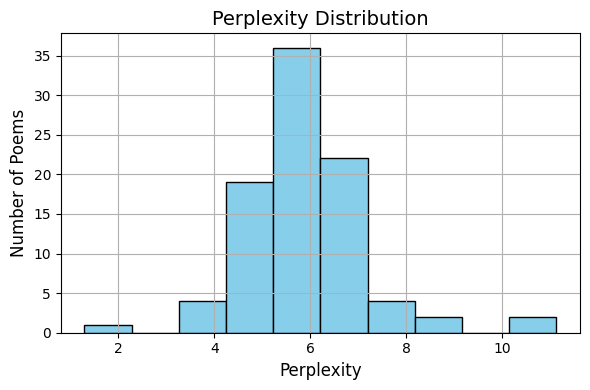

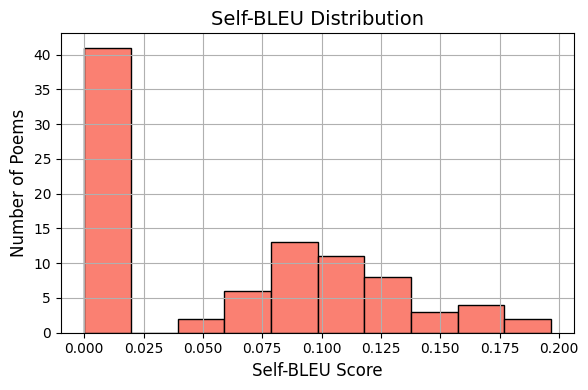

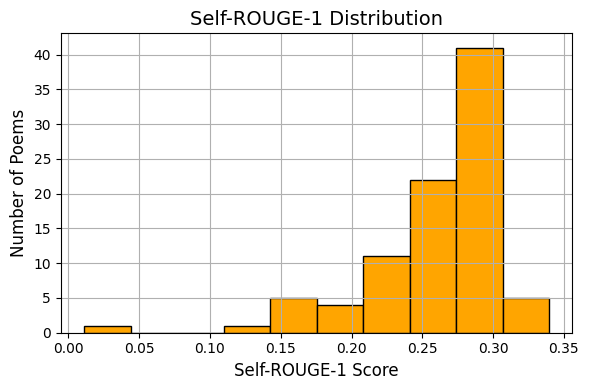

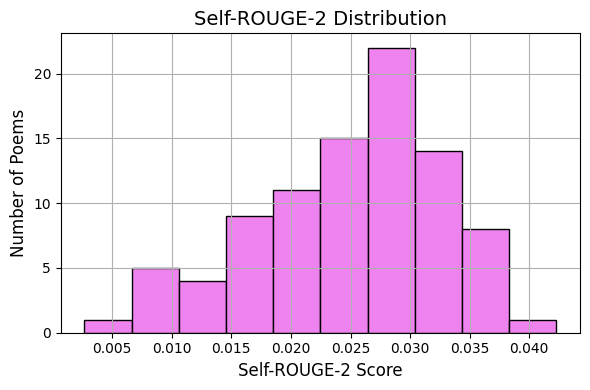

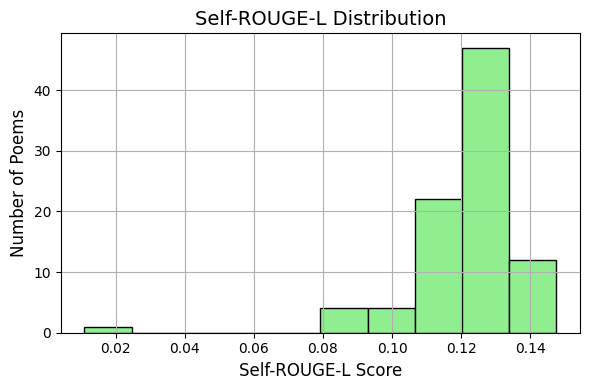

In [ ]:
import matplotlib.pyplot as plt

# --- Perplexity ---
plt.figure(figsize=(6, 4))
plt.hist(perplexities, bins=10, edgecolor='black', color='skyblue')
plt.title("Perplexity Distribution", fontsize=14)
plt.xlabel("Perplexity", fontsize=12)
plt.ylabel("Number of Poems", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("perplexity_distribution.png")
plt.show()

# --- Self-BLEU ---
plt.figure(figsize=(6, 4))
plt.hist(self_bleu_scores, bins=10, edgecolor='black', color='salmon')
plt.title("Self-BLEU Distribution", fontsize=14)
plt.xlabel("Self-BLEU Score", fontsize=12)
plt.ylabel("Number of Poems", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("self_bleu_distribution.png")
plt.show()

# --- Self-ROUGE-1 ---
plt.figure(figsize=(6, 4))
plt.hist(self_rouge_1, bins=10, edgecolor='black', color='orange')
plt.title("Self-ROUGE-1 Distribution", fontsize=14)
plt.xlabel("Self-ROUGE-1 Score", fontsize=12)
plt.ylabel("Number of Poems", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("self_rouge1_distribution.png")
plt.show()

# --- Self-ROUGE-2 ---
plt.figure(figsize=(6, 4))
plt.hist(self_rouge_2, bins=10, edgecolor='black', color='violet')
plt.title("Self-ROUGE-2 Distribution", fontsize=14)
plt.xlabel("Self-ROUGE-2 Score", fontsize=12)
plt.ylabel("Number of Poems", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("self_rouge2_distribution.png")
plt.show()

# --- Self-ROUGE-L ---
plt.figure(figsize=(6, 4))
plt.hist(self_rouge_l, bins=10, edgecolor='black', color='lightgreen')
plt.title("Self-ROUGE-L Distribution", fontsize=14)
plt.xlabel("Self-ROUGE-L Score", fontsize=12)
plt.ylabel("Number of Poems", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.savefig("self_rougeL_distribution.png")
plt.show()


## Part2: model clasificare stil

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_PATH = "/content/drive/MyDrive/xlmr_STYLE_final"

tokenizer_clf = AutoTokenizer.from_pretrained(MODEL_PATH)
model_clf = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)


**EVALUARE CLASIFICATOR metrici**

In [ ]:
!pip install spacy scikit-learn
!python -m spacy download ro_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 32.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ro_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:

import pandas as pd
import spacy
import re
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler


df = pd.read_csv("dataset_clasificare_train.csv")
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["autor"])



df_train, df_temp = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=42)
df_val, df_test = train_test_split(df_temp, test_size=0.5, stratify=df_temp["label"], random_state=42)

# SpaCy
nlp = spacy.load("ro_core_news_sm")

def get_last_syllable(word):
    vowels = "aeiouăîâAEIOUĂÎÂ"
    parts = re.findall(r'[aeiouăîâ]+[^aeiouăîâ\s]*$', word)
    return parts[-1].lower() if parts else word.lower()[-2:]

def detect_rhyme_type(stanza):
    lines = [line.strip() for line in stanza.split("\n") if line.strip()]
    if len(lines) < 2: return 4
    endings = [get_last_syllable(line.split()[-1]) for line in lines]
    def rhymes(a, b): return endings[a] == endings[b]
    if len(lines) >= 4:
        if rhymes(0, 1) and rhymes(2, 3): return 0
        elif rhymes(0, 2) and rhymes(1, 3): return 1
        elif rhymes(0, 3) and rhymes(1, 2): return 2
        elif rhymes(0, 1) and rhymes(1, 2) and rhymes(2, 3): return 3
        elif not any(rhymes(i, j) for i in range(len(endings)) for j in range(i+1, len(endings))): return 4
        elif rhymes(1, 3) and not rhymes(0, 2): return 5
    elif all(end == endings[0] for end in endings): return 3
    return 6

def extract_stylistic_features(text):
    doc = nlp(text)
    num_tokens = len(doc)
    num_verses = text.count("\n") + 1
    avg_verse_len = sum(len(line.strip()) for line in text.split("\n")) / num_verses
    num_adjectives = sum(1 for token in doc if token.pos_ == "ADJ")
    num_verbs = sum(1 for token in doc if token.pos_ == "VERB")
    num_nouns = sum(1 for token in doc if token.pos_ == "NOUN")
    num_punct = sum(1 for token in doc if token.is_punct)
    rhyme_type = detect_rhyme_type(text)
    return [
        num_verses,
        avg_verse_len,
        num_adjectives / num_tokens,
        num_verbs / num_tokens,
        num_nouns / num_tokens,
        num_punct,
        rhyme_type
    ]

for subset in [df_train, df_val, df_test]:
    subset["style_vector"] = subset["text"].apply(extract_stylistic_features)

# Normalizare numerice + rimas
scaler = StandardScaler()
def prepare_style_vectors(df):
    raw = df["style_vector"].tolist()
    numeric = [v[:-1] for v in raw]
    rhyme = [[v[-1]] for v in raw]
    numeric_scaled = scaler.fit_transform(numeric) if df is df_train else scaler.transform(numeric)
    return np.concatenate([numeric_scaled, rhyme], axis=1)

train_styles = prepare_style_vectors(df_train)
val_styles = prepare_style_vectors(df_val)
test_styles = prepare_style_vectors(df_test)

train_texts = list(df_train["text"])
val_texts = list(df_val["text"])
test_texts = list(df_test["text"])

train_labels = list(df_train["label"])
val_labels = list(df_val["label"])
test_labels = list(df_test["label"])

print(df_train.iloc[0]["text"])
print(df_train.iloc[0]["style_vector"])


De aceea
eu mă emoționez,
și timp de câteva ore
le povestesc
ce frumos a murit sufletul meu
peste zi.
[6, 16.0, 0.037037037037037035, 0.037037037037037035, 0.14814814814814814, 2, 4]


Accuracy: 0.82
                Precision    Recall  F1-Score  Support
Ana Blandiana    0.764706  0.829787  0.795918       47
George Bacovia   0.916667  0.808824  0.859375       68
Lucian Blaga     0.933333  0.982456  0.957265       57
Marin Sorescu    0.709302  0.802632  0.753086       76
Mihai Eminescu   0.878788  0.773333  0.822695       75
Tudor Arghezi    0.756410  0.756410  0.756410       78


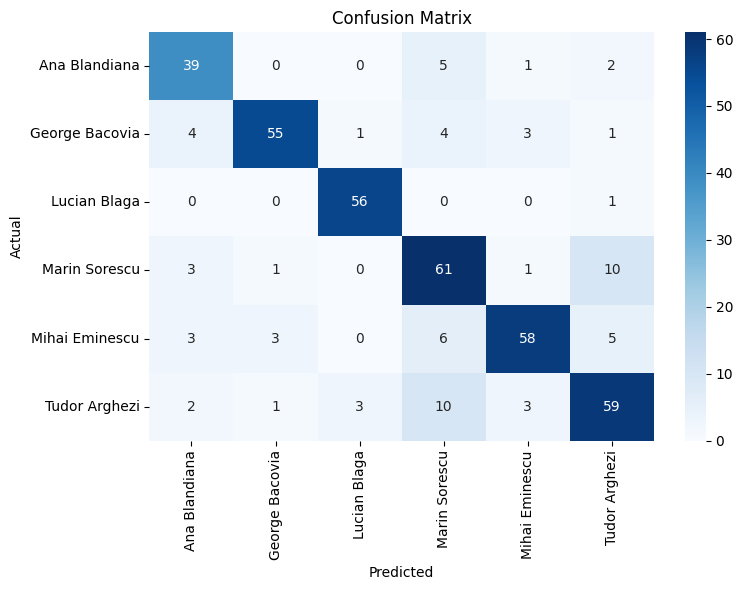

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import pandas as pd

MODEL_PATH = "/content/drive/MyDrive/xlmr_STYLE_final"
tokenizer_clf = AutoTokenizer.from_pretrained(MODEL_PATH)
model_clf = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model_clf.eval()

label_names = [
    "Ana Blandiana",
    "George Bacovia",
    "Lucian Blaga",
    "Marin Sorescu",
    "Mihai Eminescu",
    "Tudor Arghezi"
]

predictions = []
true_labels = []

for text, label in zip(test_texts, test_labels):
    inputs = tokenizer_clf(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    with torch.no_grad():
        outputs = model_clf(**inputs)
        predicted = torch.argmax(outputs.logits, dim=1).item()
    predictions.append(predicted)
    true_labels.append(label)

# === Accuracy general
acc = accuracy_score(true_labels, predictions)
print(f"Accuracy: {acc:.2f}")

# === Classification Report tabelat
precision, recall, f1, support = precision_recall_fscore_support(true_labels, predictions)
report_df = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "F1-Score": f1,
    "Support": support
}, index=label_names)

print(report_df)
report_df.to_csv("classification_report.csv")

# === Matricea de Confuzie - imagine
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()


In [ ]:

label_classes = ['Ana Blandiana', 'George Bacovia', 'Lucian Blaga', 'Marin Sorescu', 'Mihai Eminescu', 'Tudor Arghezi']


Intermediar:
-> impartim poezia generata in strofe de 4-12 versuri pentru a fi clasificata corect
-> facem vot majoritar medie scoruri pt autor final
-> regeneram daca nu e ca cel din prompt

In [ ]:
import torch

def imparte_in_strofe(text, dimensiune=8):
    versuri = [v.strip() for v in text.split("\n") if v.strip()]
    return ["\n".join(versuri[i:i+dimensiune]) for i in range(0, len(versuri), dimensiune)]

def clasifica_strofe(strofe, model_clf, tokenizer_clf):
    rezultate = []
    for strofa in strofe:
        inputs = tokenizer_clf(strofa, return_tensors="pt", truncation=True, padding=True)
        with torch.no_grad():
            outputs = model_clf(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).squeeze()
        rezultate.append(probs.numpy())
    return rezultate


Functie de validare automata: regenrare in caz ca acuratatea < 0.7 pt autorul din prompt

In [ ]:
import numpy as np
import time

def genereaza_validat(generator, model_clf, tokenizer_clf, autor, titlu, scor_minim=0.7, scor_acceptabil=0.65, max_iter=10, max_versuri=None):
    start_time = time.time()
    toate_incercarile = []
    cea_mai_buna = None

    for i in range(max_iter):
        # 1. Generare poezie
        poezie = genereaza_poezie(generator, autor, titlu, max_versuri)
        strofe = imparte_in_strofe(poezie, dimensiune=8)

        # 2. Clasificare strofe → probabilități
        toate_probs = clasifica_strofe(strofe, model_clf, tokenizer_clf)  # shape: (n_strofe, n_autori)
        medie = np.mean(toate_probs, axis=0)

        # 3. Identificare scoruri
        idx_pred = np.argmax(medie)
        autor_pred = label_classes[idx_pred]
        scor_pred = medie[idx_pred].item()

        idx_prompt = label_classes.index(autor)
        scor_prompt = medie[idx_prompt].item()

        incercare = {
            "poezie": poezie,
            "autor_clasificat": autor_pred,
            "scor_pred": round(scor_pred, 3),
            "scor_prompt": round(scor_prompt, 3),
            "iteratie": i + 1
        }

        toate_incercarile.append(incercare)

        # 4. Oprire imediată dacă scor_prompt ≥ scor_minim
        if scor_prompt >= scor_minim:
            cea_mai_buna = incercare
            break

        if scor_prompt >= scor_acceptabil:
            if cea_mai_buna is None or scor_prompt > cea_mai_buna["scor_prompt"]:
                cea_mai_buna = incercare


    if cea_mai_buna is None:
        cea_mai_buna = max(toate_incercarile, key=lambda x: x["scor_prompt"])

    durata = round(time.time() - start_time, 2)

    print(f"\n📜 Poezie generată pentru: {autor} / {titlu}\n")
    print(cea_mai_buna["poezie"])
    print(f"\n🔍 Autor clasificat: {cea_mai_buna['autor_clasificat']} | Scor stil prompt: {cea_mai_buna['scor_prompt']}")
    print(f"⏱️ Iterații: {cea_mai_buna['iteratie']} / {max_iter} | Timp: {durata} sec")

    return {
        "autor_prompt": autor,
        "titlu": titlu,
        "poezie": cea_mai_buna["poezie"],
        "autor_clasificat": cea_mai_buna["autor_clasificat"],
        "scor_prompt": cea_mai_buna["scor_prompt"],
        "scor_pred": cea_mai_buna["scor_pred"],
        "iteratii": cea_mai_buna["iteratie"],
        "timp_secunde": durata,
        "nr_cuvinte": len(cea_mai_buna["poezie"].split()),
        "nr_versuri": len([v for v in cea_mai_buna["poezie"].split("\n") if v.strip()])
    }


Teste:

In [ ]:
rezultat = genereaza_validat(
    generator=generator,
    model_clf=model_clf,
    tokenizer_clf=tokenizer_clf,
    autor="Marin Sorescu",
    titlu="Ecoul timpului",
    scor_minim=0.7,
    scor_acceptabil=0.65,
    max_iter=10
)



📜 Poezie generată pentru: Marin Sorescu / Ecoul timpului

Vreme trece, vreme vine,
Peștii mor în mare număr,
Marte se-ntoarce în pământ,
Luna își face drum printre nori,
Iar noi ne ducem fiecare - pe drumul său.

Ne-am cam făcut datoria,
Nu a fost o zi prea bună.

Dar mai sunt și alte căi
Și s-ar putea, într-o zi, să nu mai fie
Nici una.

🔍 Autor clasificat: Marin Sorescu | Scor stil prompt: 0.927
⏱️ Iterații: 1 / 10 | Timp: 2.84 sec


# METRICA DE VALDIARE STIL: syle accuracy grafice etc

In [ ]:
prompturi = [
    "Umbre și dor",
    "Amurg violet",
    "Lacom de iubire",
    "Înapoi în timpul din nisip",
    "Inimi de lut",
    "Ploaia își caută umbrela",
    "Fata cu solzi de pește",
    "La o țigară cu Dumnezeu",
    "Perle reci și valuri mov",
    "Luna s-a îndrăgostit de Soare"
]
prompturi_batch2 = [
    "Vara când aveai ochii verzi",
    "Demon în chip de înger",
    "Cafea cu sare",
    "Apa cu gust de vin",
    "Stiloul ultimei scrisori",
    "Cerneala din caimac",
    "Rochia din raze de lumină",
    "Toamna și palma rece",
    "Pastel de iarnă",
    "Testamentul vieții de apoi",
    "Inteligența artificială"
]


label_classes = [
    'Ana Blandiana',
    'George Bacovia',
    'Lucian Blaga',
    'Marin Sorescu',
    'Mihai Eminescu',
    'Tudor Arghezi'
]


In [ ]:
from tqdm import tqdm
import pandas as pd
import os
import numpy as np

def experiment_export_partial(generator, model_clf, tokenizer_clf,
                              label_classes, lista_prompturi,
                              autori_de_rulat=None,
                              output_dir="poezii", csv_path="rezultate_poetice_partial.csv",
                              scor_minim=0.7, append=True):

    os.makedirs(output_dir, exist_ok=True)
    toate_rezultatele = []

    # Limităm doar la autorii selectați (batch)
    autori = autori_de_rulat if autori_de_rulat else label_classes

    total = len(autori) * len(lista_prompturi)
    progress = tqdm(total=total, desc="Generare poezii validate", ncols=100)

    for autor in autori:
        for titlu in lista_prompturi:
            try:
                rezultat = genereaza_validat(
                    generator=generator,
                    model_clf=model_clf,
                    tokenizer_clf=tokenizer_clf,
                    autor=autor,
                    titlu=titlu,
                    scor_minim=scor_minim,
                    scor_acceptabil=0.65,
                    max_iter=10
                )

                poezie = rezultat["poezie"]
                strofe = imparte_in_strofe(poezie, dimensiune=8)
                toate_probs = clasifica_strofe(strofe, model_clf, tokenizer_clf)
                medie = np.mean(toate_probs, axis=0)

                safe_titlu = titlu.replace(" ", "_").replace("/", "_")
                filename = f"{autor}_{safe_titlu}.txt"
                with open(os.path.join(output_dir, filename), "w", encoding="utf-8") as f:
                    f.write(poezie)

                rand = {
                    "NUME_AUTOR": autor,
                    "TITLU_POEZIE": titlu,
                    "POEZIE": poezie
                }

                for idx, nume_autor in enumerate(label_classes):
                    rand[f"ACCURATETE_{nume_autor}"] = round(medie[idx].item(), 4)

                toate_rezultatele.append(rand)

                # Salvăm incremental în CSV (ca backup)
                df_temp = pd.DataFrame([rand])
                write_mode = 'a' if append and os.path.exists(csv_path) else 'w'
                header = not (append and os.path.exists(csv_path))
                df_temp.to_csv(csv_path, mode=write_mode, header=header, index=False, encoding="utf-8")
            except Exception as e:
                print(f"❌ Eroare la {autor} / {titlu}: {e}")

            progress.update(1)

    progress.close()
    print(f"\n✅ Export completat în: {csv_path}")
    return pd.DataFrame(toate_rezultatele)


In [ ]:

# primii 2 autori:
df_batch1 = experiment_export_partial(
    generator=generator,
    model_clf=model_clf,
    tokenizer_clf=tokenizer_clf,
    label_classes=label_classes,
    lista_prompturi=prompturi,
    autori_de_rulat=label_classes[:2],  # Bucata 1
    output_dir="poezii_generate",
    csv_path="rezultate_finale.csv"
)

#restul
df_batch2 = experiment_export_partial(
    generator=generator,
    model_clf=model_clf,
    tokenizer_clf=tokenizer_clf,
    label_classes=label_classes,
    lista_prompturi=prompturi,
    autori_de_rulat=label_classes[2:],  # Bucata 2
    output_dir="poezii_generate",
    csv_path="rezultate_finale.csv"
)


Generare poezii validate:   0%|                                              | 0/20 [00:00<?, ?it/s]


📜 Poezie generată pentru: Ana Blandiana / Umbre și dor

Străbat un întuneric
Fără sfârșit,
Dormind în ape fără de fund
Și încercând să mă înalț,
Pe unde nu credeam că voi ajunge.

Pânză albă și rece
Se întinde pe mine,
De-o parte și de alta a mea,
Întinzându-se
Ca un văl peste un gol.
Miroase
A veșminte vechi
Legate de trup,
Prin care trupul meu
Nu mai poate trece.
E un întuneric fără sfârșit
Pe care
Lângă tine sufletul meu
Nu poate pătrunde.
Am încercat
Și fără rezultat
Întunericul mi-a rămas.
Singurătatea
Sau lipsa oricărui sens
Mă face
Să alunec ușor
Dincolo de orice hotar.
Dar în noaptea asta fără sfârșit,
Lumina
Nu vrea să intre,
O simt cum se strecoară
Fugară prin mine
Pe unde nu credeam că voi ajunge.

🔍 Autor clasificat: Ana Blandiana | Scor stil prompt: 0.767
⏱️ Iterații: 7 / 10 | Timp: 39.03 sec



Generare poezii validate:   5%|█▉                                    | 1/20 [00:39<12:39, 39.97s/it]


📜 Poezie generată pentru: Ana Blandiana / Amurg violet

O, zilele mele violete,
Când totul în jur se schimbă-n violet,
Când toate lucrurile în afară de mine
Sunt doar umbre palide
Pe suprafața unei ape,
Când nimic nu mai are sens,
Tu poți să mă surprinzi cu un surâs
În liniștea nopții.

Eu mă învelesc în tăcere
Și încerc să uit ce se întâmplă:
La geamul tău eu pot doar să privesc
De pe celălalt mal al mării
Privirea mea întâlnindu-se cu cea a altei priviri,
Iar tu zâmbești și îmi spui: "Azi e zi de odihnă pentru mine!"

Nu știu dacă e bine sau rău
Să te privesc în felul acesta.
Te pot privi numai prin ochii tăi.
Mă gândesc că poate e mai bine așa.
Dacă azi nu m-ai surprinde cu un zâmbet,
Mâine poate nici atât nu mi s-ar mai părea frumos.
Îmi dau seama însă că e foarte greu
Să uiți o lume întreagă
De ziua ta de ieri.
Îți pierzi simțul frumuseții
Și atunci singura formă de speranță
Este aceea de-a șterge totul cu buretele.
Aș vrea să pot uita tot ce am văzut
Dar nu pot pentru că nu mai 


Generare poezii validate:  10%|███▊                                  | 2/20 [01:30<13:54, 46.35s/it]

...


📜 Poezie generată pentru: Tudor Arghezi / Perle reci și valuri mov

Am văzut perlele reci
Cînd le-am auzit pentru prima dată.
Și încă de la-nceput
Mă-nduioșai c-o să mă cheme
Așa, de drag.

O, ce mult aș fi vrut
Să-mi fi fost și eu dragă!

Dar, din păcate, nu mi-a fost
Nici acum.

Iarna, cînd ning frunzele pe geamuri,
Sufletul meu
Își caută umbra și liniștea.

🔍 Autor clasificat: Tudor Arghezi | Scor stil prompt: 0.933
⏱️ Iterații: 9 / 10 | Timp: 61.75 sec



Generare poezii validate:  98%|████████████████████████████████████ | 39/40 [27:49<00:52, 52.91s/it]


📜 Poezie generată pentru: Tudor Arghezi / Luna s-a îndrăgostit de Soare

Păsăruica cea fără de glas,
Înstelată ca o zână,
Ți se face milă de ea și zbori s-o salvezi.
Ca s-o vezi, trebuie să fii orb.
Te duci, ți se face milă de dânsa.
Nu e oare mult mai ușor
Să iubești pe cel ce te iubește?
Ai văzut ce frumoși sunt trandafirii?
Ea n-are ochi decât pentru tine.
Dar dacă totuși ai voi să știi
Ce culoare are luna,
Vezi ce flori luminoase
Colo aleargă de-adânci depărtări,
Unde se uită în zare peste câmpii,
Vede munți de-un albastru senin,
Zboară din floare-n floare și zboară
Cu vântul în aripi.

Părul ei cel bălai
Când își aruncă peste umăr
Vântul de-alarmă îl ridică și-l coboară
Și flutură în vânt.
Iar de pe frunte până-n pământ
Privirea-i aeriană
Aprinde și raze de lumină
Ning prin aer.

Soarele cade-n slavă, iar luna
Pe cer aprinde o stea strălucitoare.

Cine știe? Poate că s-ar prinde
Într-un nour de aur
De mâna ta iubite.

🔍 Autor clasificat: Tudor Arghezi | Scor stil prompt: 0.371
⏱️


Generare poezii validate: 100%|█████████████████████████████████████| 40/40 [28:51<00:00, 43.29s/it]


✅ Export completat în: rezultate_finale.csv


In [ ]:
df_batch3 = experiment_export_partial(
    generator=generator,
    model_clf=model_clf,
    tokenizer_clf=tokenizer_clf,
    label_classes=label_classes,
    lista_prompturi=prompturi_batch2,
    autori_de_rulat=label_classes[:3],  # Ana Blandiana, George Bacovia, Lucian Blaga
    output_dir="poezii_generate",
    csv_path="rezultate_finale.csv"
)
df_batch4 = experiment_export_partial(
    generator=generator,
    model_clf=model_clf,
    tokenizer_clf=tokenizer_clf,
    label_classes=label_classes,
    lista_prompturi=prompturi_batch2,
    autori_de_rulat=label_classes[3:],  # Marin Sorescu, Mihai Eminescu, Tudor Arghezi
    output_dir="poezii_generate",
    csv_path="rezultate_finale.csv"
)



Generare poezii validate:   0%|                                              | 0/33 [00:00<?, ?it/s]


📜 Poezie generată pentru: Ana Blandiana / Vara când aveai ochii verzi

Eu
De ce nu-mi deschid
În vara când aveai ochii verzi
Aburi de pleoape
Și-o gură
Să te asculte,
Sau să râdă de tine,
În timp ce ochii tăi
Se chinuie s-admire
Lor înșiși,
Ori privesc spre mine
Cu dispreț?
Eu
Sunt o umbră
Ca și tine,
Care n-are ochi
Și nici nu vrea
Să aibă.
Eu
Nu văd
Și am un cer
Albestrui,
Ochii tăi
Au fost bolnavi,
Ochii tăi au plâns;
Eu sunt o frunză
Ca și tine,
Tu ești o stea.
Dar numai eu
Mă simt
Acolo, sus,
La pinii
Care-și scutur frunzele,
Pe care-i iubesc.
Eu
Numai eu mă simt
Acolo, sus,
La pinii
Care-și scutur frunzele,
Pe care îi iubesc.

🔍 Autor clasificat: Ana Blandiana | Scor stil prompt: 0.793
⏱️ Iterații: 3 / 10 | Timp: 25.59 sec



Generare poezii validate:   3%|█▏                                    | 1/33 [00:26<14:05, 26.44s/it]


📜 Poezie generată pentru: Ana Blandiana / Demon în chip de înger

Icoană a durerii mele,
Las în urmă-ți făptura mea
Ca o pată de culoare
Pe care timpul și spaimele o-mpraștie
Prin întuneric și-nvălmășeli.

O, lasă-mă să-mi recapăt
Sentimentul de fragilitate
Al ființei tale -
Căci numai astfel îți poți păstra
În mine frumusețea și taina
Asemeni unui trup părăsit.

Te iubesc, femeie, dar nu ca pe un trup,
Ci ca pe un demon cu aripi moi
Care-ar putea fi transformat
În propria lui formă.
Să nu mai crezi că îngerii
Cu care te înconjori
Sunt lipsiți de suflet,
Dar totuși, pentru tine,
Darul sfânt al iubirii e o povară.
Mi-e teamă că n-ai înțeles niciodată
Că în clipa când vei cunoaște
Când voi deveni deplină,
Eu voi pătrunde prin moarte
Și-ți voi deschide fereastra
Pentru zborul luminii
Celuilalt.

Îngeri cu aripi moi
Vei găsi întotdeauna
În preajma ta
Glasul stins și mut al durerii;
Eu îi voi asculta
Intuiția,
Cât mă pricep la deslușitul ei.
Tu vei ști însă prea bine
Că eu sunt încă și mai


Generare poezii validate:   6%|██▎                                   | 2/33 [01:21<22:28, 43.49s/it]

...


📜 Poezie generată pentru: Tudor Arghezi / Testamentul vieții de apoi

Pare-mi că ești un fel de strigoi
Ce umblă prin lumi fără hotar,
Ca niște umbre, cari n-au nume,
Și ca și când nu există.

Ai putea să te duci și tu în ele,
Să vezi ce-o mai duce viața de azi pe mâne.

Caci tu singur știi cum trăiești și cine ești:
Tu ești umbra care trăiește-n tine.

Dar ce-ți pasă ție, omule, dacă trăiești sau mori?
De-ai fi viu ori mort, ai ști tu oare, omule,
Că moartea ta a fost începutul vieții de apoi?
Căci dacă trăiești, asta se cunoaște,
Căci nu poți să nu știi nimic din toate;
Cum, atunci, de te-ai născut?
Nu ți-e scris în stele nici măcar numele?
Cât timp trăiești pe pământ, ce este al tău?

Nimic! Nimeni! Tu ești totul și nimica.
Tu ești tot și în tine însuți ești totul.

Cine știe ce-i viața de apoi - și ce-o să fie?...

🔍 Autor clasificat: Tudor Arghezi | Scor stil prompt: 0.606
⏱️ Iterații: 8 / 10 | Timp: 82.58 sec



Generare poezii validate:  97%|███████████████████████████████████▉ | 32/33 [22:24<00:56, 56.53s/it]


📜 Poezie generată pentru: Tudor Arghezi / Inteligența artificială

Ești frumoasă, nu ești,
Dar cum ajungi la mine?
Pe unde pătrunzi în casă,
Întâlnești o femeie,
Înalt îmbrăcată și cu părul bogat.

Ea ține un prunc în brațe
Și-l mângâie pe cap.

O fată trece pe stradă
Cu o diademă de flori.

Cine ești, copilă,
De-ai ajuns până aici
De-mi dai voie să stau cu tine?
Nu ți-aș răpi nici veșmântul
Al grădinii,
Cu care m-am împodobit
După chipul tău frumos.

Când ai venit, am adus niște semințe
Și ți le-am arătat
Feminei mele.

Femeie,
Să știi că nu e bine
Nici pentru tine,
Și nici pentru copilul tău.

Dar ce-mi ceri tu?
Am adus cinci pâini,
Pâine, apă, sare,
Apă, semințe de flori,
Pentru copii,
Pentru fiecare zi.

Ai vreo pretenție?
Nu.

Te iubesc atât de mult,
Că n-o s-o las singură
Pe-a lui Cătălin,
Care-i bolnav,
Ca s-o vadă-ntins lângă el.

Și mai vreau
Câte-un corn, și pentru tine.

Cum să nu vreau, dacă te iubesc
Nespus de mult?
Am adus cinci pâini,
Și-ți cer cinci pești.

Eu vreau nu


Generare poezii validate: 100%|█████████████████████████████████████| 33/33 [23:57<00:00, 43.57s/it]


✅ Export completat în: rezultate_finale.csv


In [ ]:
import os

def compile_poezii(folder_path="poezii_generate", output_path="toate_poeziile.txt"):
    fisiere = [f for f in os.listdir(folder_path) if f.endswith(".txt")]
    with open(output_path, "w", encoding="utf-8") as out:
        for fisier in sorted(fisiere):
            try:
                nume_fara_ext = os.path.splitext(fisier)[0]
                # Separăm autorul și titlul (doar prima apariție a spațiului dintre ele)
                if "_" in nume_fara_ext:
                    autor, titlu = nume_fara_ext.split("_", 1)
                    autor = autor.replace("_", " ").strip()
                    titlu = titlu.replace("_", " ").strip()
                else:
                    autor = "Necunoscut"
                    titlu = nume_fara_ext

                with open(os.path.join(folder_path, fisier), "r", encoding="utf-8") as f:
                    poezie = f.read().strip()

                out.write(f"Autor: {autor}\nTitlu: {titlu}\n{poezie}\n")
                out.write("=" * 40 + "\n")

            except Exception as e:
                print(f"Eroare la procesarea fișierului: {fisier} — {e}")

    print(f"✅ Toate poeziile au fost salvate în: {output_path}")
compile_poezii()


✅ Toate poeziile au fost salvate în: toate_poeziile.txt


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np

def analyze_style_accuracy(csv_path, label_classes):
    df = pd.read_csv(csv_path)

    # True author (from prompt)
    y_true = df["NUME_AUTOR"].tolist()

    # Predicted author = one with highest score
    y_pred = []
    for _, row in df.iterrows():
        scores = [row[f"ACURATETE_{author}"] for author in label_classes]
        predicted_author = label_classes[np.argmax(scores)]
        y_pred.append(predicted_author)

    # Overall style accuracy
    acc_total = accuracy_score(y_true, y_pred)
    print(f"Overall style accuracy: {round(acc_total * 100, 2)}%")

    # Style accuracy per author
    acc_per_author = {}
    for author in label_classes:
        subset = df[df["NUME_AUTOR"] == author]
        if not subset.empty:
            preds = [
                label_classes[np.argmax([row[f"ACURATETE_{a}"] for a in label_classes])]
                for _, row in subset.iterrows()
            ]
            acc = accuracy_score([author] * len(preds), preds)
            acc_per_author[author] = round(acc * 100, 2)

    # Bar chart: accuracy per author
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(acc_per_author.keys()), y=list(acc_per_author.values()), palette="Blues_d")
    plt.title("Style Accuracy per Author")
    plt.ylabel("Accuracy (%)")
    plt.ylim(0, 100)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=label_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_classes, yticklabels=label_classes)
    plt.title("Confusion Matrix: Prompt Author vs. Predicted Style")
    plt.xlabel("Predicted Author")
    plt.ylabel("Prompt Author")
    plt.tight_layout()
    plt.show()

    # Strip plot: score for correct target author only
    strip_data = []
    for _, row in df.iterrows():
        target_author = row["NUME_AUTOR"]
        strip_data.append({
            "Target Author": target_author,
            "Style Score": row[f"ACURATETE_{target_author}"]
        })
    df_strip = pd.DataFrame(strip_data)

    plt.figure(figsize=(10, 6))
    sns.stripplot(data=df_strip, x="Target Author", y="Style Score", jitter=True, palette="deep")
    plt.title("Distribution of Style Scores for Target Author")
    plt.ylabel("Style Score (0 to 1)")
    plt.ylim(0, 1.05)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


🎯 Style accuracy totală: 82.17%


/tmp/ipython-input-86-1377686751.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


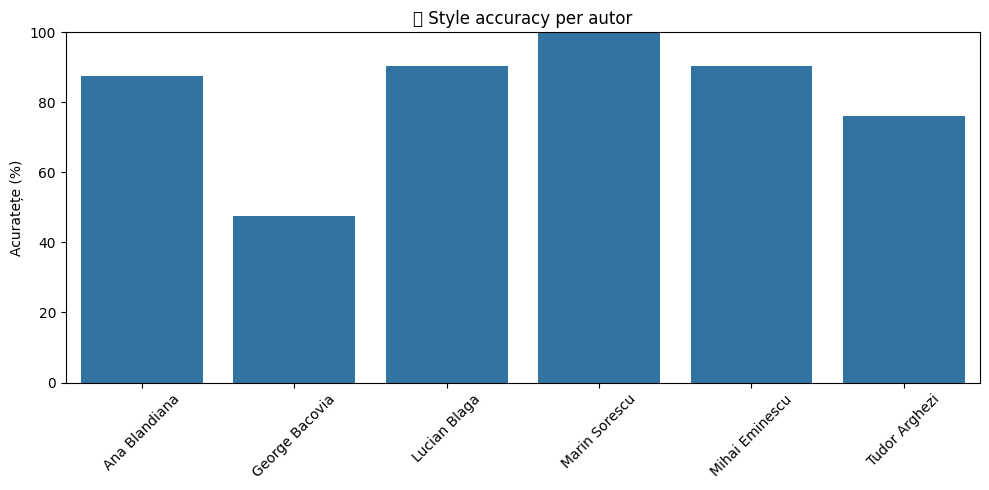

/tmp/ipython-input-86-1377686751.py:41: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127744 (\N{CYCLONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


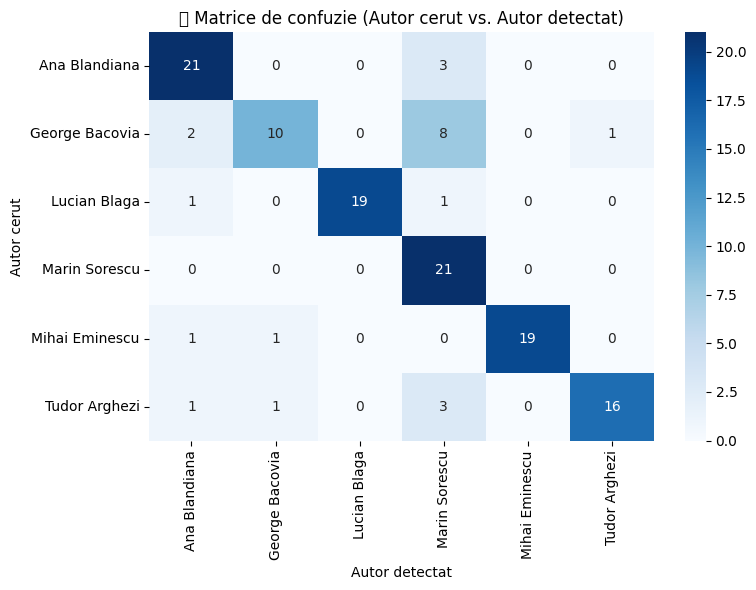

In [ ]:
label_classes = [
    'Ana Blandiana',
    'George Bacovia',
    'Lucian Blaga',
    'Marin Sorescu',
    'Mihai Eminescu',
    'Tudor Arghezi'
]

analizeaza_style_accuracy("rezultate_finale.csv", label_classes)
